In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
products = pd.read_csv("../ecommerce_dataset/products.csv")

customers = pd.read_csv("../ecommerce_dataset/users.csv")

orders = pd.read_csv("../ecommerce_dataset/orders.csv")

order_items = pd.read_csv("../ecommerce_dataset/order_items.csv")

In [4]:
sales_df = order_items.merge(
    products,
    on="product_id",
    how="left"
)
sales_df = sales_df.merge(
    orders,
    on=["order_id", "user_id"],
    how="left"
)

In [5]:

sales_df.head()
sales_df.info()
sales_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43525 entries, 0 to 43524
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  43525 non-null  object 
 1   order_id       43525 non-null  object 
 2   product_id     43525 non-null  object 
 3   user_id        43525 non-null  object 
 4   quantity       43525 non-null  int64  
 5   item_price     43525 non-null  float64
 6   item_total     43525 non-null  float64
 7   product_name   43525 non-null  object 
 8   category       43525 non-null  object 
 9   brand          43525 non-null  object 
 10  price          43525 non-null  float64
 11  rating         43525 non-null  float64
 12  order_date     43525 non-null  object 
 13  order_status   43525 non-null  object 
 14  total_amount   43525 non-null  float64
dtypes: float64(5), int64(1), object(9)
memory usage: 5.0+ MB


(43525, 15)

In [6]:
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])

monthly_sales = (
    sales_df
    .groupby(
        sales_df["order_date"].dt.to_period("M")
    )["item_total"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,order_date,item_total
0,2024-01,543120.43
1,2024-02,513712.79
2,2024-03,541213.26
3,2024-04,545624.46
4,2024-05,552700.82


In [7]:
monthly_sales.rename(
    columns={
        "order_date":"Month",
        "item_total":"Revenue"
    },
    inplace=True
)
monthly_sales.head()

,Month,Revenue
0,2024-01,543120.43
1,2024-02,513712.79
2,2024-03,541213.26
3,2024-04,545624.46
4,2024-05,552700.82


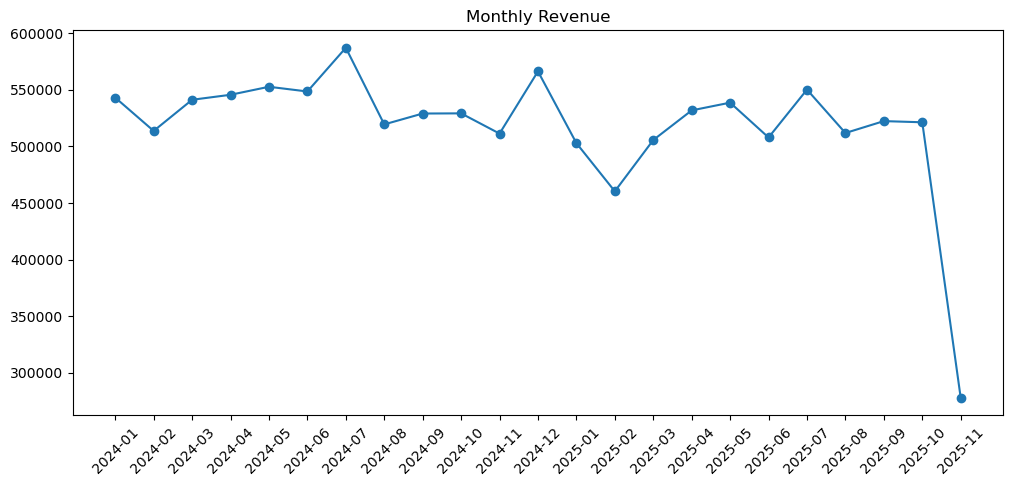

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales["Revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.show()

prophet


In [9]:
from prophet import Prophet

In [10]:
forecast_df = monthly_sales.rename(
    columns={
        "Month": "ds",
        "Revenue": "y"
    }
)

forecast_df.head()

,ds,y
0,2024-01,543120.43
1,2024-02,513712.79
2,2024-03,541213.26
3,2024-04,545624.46
4,2024-05,552700.82


In [11]:
forecast_df["ds"] = forecast_df["ds"].astype(str)

forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])

In [12]:
model = Prophet()

In [13]:
model.fit(forecast_df)

12:39:04 - cmdstanpy - INFO - Chain [1] start processing


12:39:05 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = model.make_future_dataframe(
    periods=6,
    freq="M"
)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [15]:
forecast = model.predict(future)
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
19,2025-08-01,485284.629429,422418.638585,541985.821899
20,2025-09-01,481167.770212,418430.736701,543890.915574
21,2025-10-01,477183.712905,413688.682447,545167.848462
22,2025-11-01,473066.853688,408666.076606,533582.274039
23,2025-11-30,469215.598292,400518.517859,530709.194525
24,2025-12-31,465098.739075,402720.671537,532128.713570
25,2026-01-31,460981.879858,398494.052608,530160.705361
26,2026-02-28,457263.426372,390081.228585,521548.224450
27,2026-03-31,453146.567155,390131.842122,520099.188303
28,2026-04-30,449162.509848,378884.885221,515363.238316


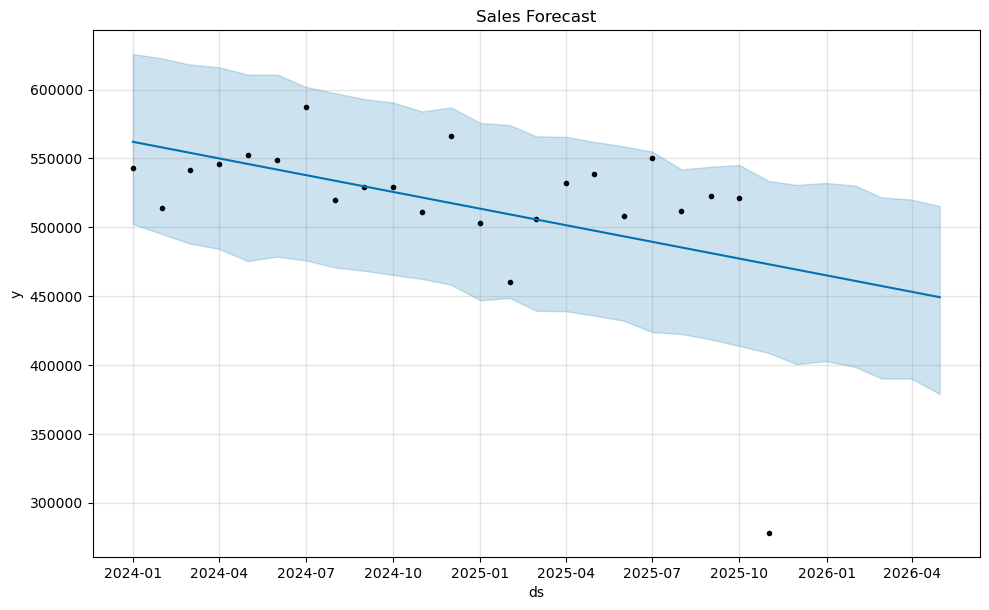

In [16]:
fig = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

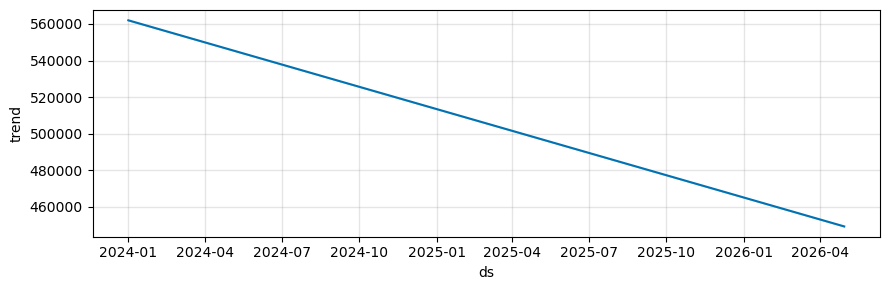

In [17]:
fig2 = model.plot_components(forecast)
plt.show()

In [18]:
forecast_df = forecast_df.iloc[:-1]
forecast_df

,ds,y
0,2024-01-01,543120.43
1,2024-02-01,513712.79
2,2024-03-01,541213.26
3,2024-04-01,545624.46
4,2024-05-01,552700.82
5,2024-06-01,548534.32
6,2024-07-01,587135.76
7,2024-08-01,519474.77
8,2024-09-01,529067.12
9,2024-10-01,529215.48


In [19]:
forecast_df.tail()

,ds,y
17,2025-06-01,507913.96
18,2025-07-01,550200.98
19,2025-08-01,511865.24
20,2025-09-01,522376.37
21,2025-10-01,521334.46


In [20]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
26,2026-02-28,457263.426372,390081.228585,521548.224450
27,2026-03-31,453146.567155,390131.842122,520099.188303
28,2026-04-30,449162.509848,378884.885221,515363.238316


In [22]:
import joblib

joblib.dump(model, "../models/sales_forecast_model.pkl")


['../models/sales_forecast_model.pkl']

In [24]:
model = joblib.load("../models/sales_forecast_model.pkl")